# Danish Housing Price Forecasting
## Notebook 2: Feature Engineering & Stationarity

**Goals:**
1. Test stationarity formally (Augmented Dickey-Fuller)
2. Transform non-stationary series to stationary
3. Handle missing values
4. Create lagged and rolling features
5. Save cleaned dataset ready for modelling

**Input:** `data/processed/combined_raw.csv`  
**Output:** `data/processed/features.csv`

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

plt.rcParams['figure.figsize'] = (12, 4)
#plt.rcParams['axes.grid'] = True
#plt.rcParams['grid.alpha'] = 0.3

# Load combined raw data
df = pd.read_csv('../data/processed/combined_raw.csv', index_col=0, parse_dates=True)

# Ensure index is DatetimeIndex
df.index = pd.to_datetime(df.index)
df.index.name = 'date'

print('Shape:', df.shape)
print('Index type:', type(df.index))
print('Date range:', df.index.min(), 'to', df.index.max())
df.tail()

Shape: (35, 4)
Index type: <class 'pandas.DatetimeIndex'>
Date range: 2017-07-01 00:00:00 to 2026-01-01 00:00:00


,house_price_index,interest_rate,unemployment,population
date,,,,
2025-01-01,104.6,3.943000,3.066667,5992734.0
2025-04-01,105.6,3.852000,2.733333,5999677.0
2025-07-01,107.7,3.668000,2.800000,6002420.0
2025-10-01,110.4,3.591667,2.700000,6019866.0
2026-01-01,112.3,3.801000,3.266667,6025603.0


---
## 1. Missing value handling

Short gaps (1-2 quarters) are interpolated linearly.  
We document every choice made here.

In [22]:
# Check for gaps
for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        print(f'{col}: {n_missing} missing values')
        # Find where the gaps are
        gaps = df[df[col].isnull()].index.tolist()
        print(f'  Gap dates: {gaps[:5]}{" ..." if len(gaps) > 5 else ""}')
    else:
        print(f'{col}: no missing values')

house_price_index: no missing values
interest_rate: no missing values
unemployment: no missing values
population: no missing values


In [23]:
# Interpolate short gaps (<=2 consecutive quarters) linearly
# For longer gaps, forward fill as a conservative choice
df_clean = df.copy()

for col in df_clean.columns:
    n_before = df_clean[col].isnull().sum()
    if n_before > 0:
        df_clean[col] = df_clean[col].interpolate(method='linear', limit=2)
        df_clean[col] = df_clean[col].ffill()  # forward fill any remaining
        n_after = df_clean[col].isnull().sum()
        print(f'{col}: {n_before} → {n_after} missing (interpolated {n_before - n_after})')

print('\nRemaining missing values:')
print(df_clean.isnull().sum())


Remaining missing values:
house_price_index    0
interest_rate        0
unemployment         0
population           0
dtype: int64


---
## 2. Stationarity tests (Augmented Dickey-Fuller)

**Null hypothesis:** the series has a unit root (non-stationary)  
**Reject H0** if p-value < 0.05 → series is stationary

In [24]:
def adf_test(series, name):
    """Run ADF test and print result clearly."""
    clean = series.dropna()
    result = adfuller(clean, autolag='AIC')
    p = result[1]
    stationary = p < 0.05
    status = '✓ STATIONARY' if stationary else '✗ NON-STATIONARY'
    print(f'{name:35s} | p={p:.4f} | {status}')
    return stationary

print('ADF Test Results — Levels')
print('-' * 65)
results_levels = {}
for col in df_clean.columns:
    results_levels[col] = adf_test(df_clean[col], col)

ADF Test Results — Levels
-----------------------------------------------------------------
house_price_index                   | p=0.8867 | ✗ NON-STATIONARY
interest_rate                       | p=0.5235 | ✗ NON-STATIONARY
unemployment                        | p=0.4114 | ✗ NON-STATIONARY
population                          | p=0.9829 | ✗ NON-STATIONARY


In [25]:
# First differences — quarter-on-quarter change
df_diff = df_clean.diff(1).dropna()

print('ADF Test Results — First Differences')
print('-' * 65)
results_diff = {}
for col in df_diff.columns:
    results_diff[col] = adf_test(df_diff[col], f'd({col})')

ADF Test Results — First Differences
-----------------------------------------------------------------
d(house_price_index)                | p=0.0877 | ✗ NON-STATIONARY
d(interest_rate)                    | p=0.0779 | ✗ NON-STATIONARY
d(unemployment)                     | p=0.0129 | ✓ STATIONARY
d(population)                       | p=0.5667 | ✗ NON-STATIONARY


In [27]:
# Second differences for non-stationary series after first differencing
df_diff2 = df_diff.diff(1).dropna()

print('ADF Test Results — Second Differences')
print('-' * 65)
non_stationary = ['house_price_index', 'interest_rate', 'population']
for col in non_stationary:
    if col in df_diff2.columns:
        adf_test(df_diff2[col], f'd2({col})')

ADF Test Results — Second Differences
-----------------------------------------------------------------
d2(house_price_index)               | p=0.0000 | ✓ STATIONARY
d2(interest_rate)                   | p=0.0000 | ✓ STATIONARY
d2(population)                      | p=0.0000 | ✓ STATIONARY


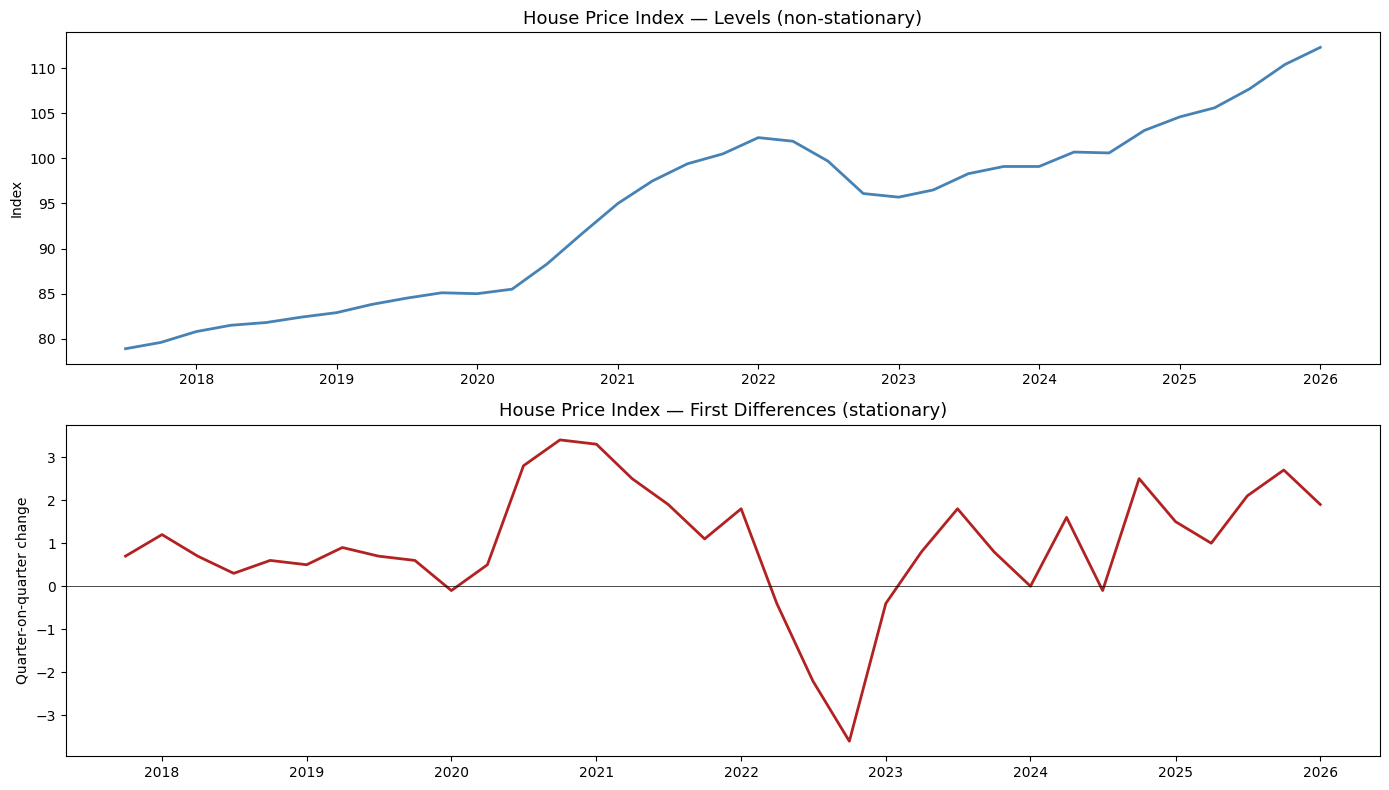

In [29]:
# Plot levels vs first differences for house price index
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_clean.index, df_clean['house_price_index'], color='steelblue', linewidth=2)
axes[0].set_title('House Price Index — Levels (non-stationary)', fontsize=13)
axes[0].set_ylabel('Index')

axes[1].plot(df_diff.index, df_diff['house_price_index'], color='firebrick', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('House Price Index — First Differences (stationary)', fontsize=13)
axes[1].set_ylabel('Quarter-on-quarter change')

plt.tight_layout()
plt.savefig('../data/processed/plot_stationarity.png', dpi=150)
plt.show()

---
## 3. Year-on-year percentage change

This is the most interpretable target variable for a housing model —  
"prices rose X% compared to the same quarter last year".

ADF Test Results — Year-on-Year % Change
-----------------------------------------------------------------
house_price_index_yoy               | p=0.0165 | ✓ STATIONARY
interest_rate_yoy                   | p=0.2610 | ✗ NON-STATIONARY
unemployment_yoy                    | p=0.1421 | ✗ NON-STATIONARY
population_yoy                      | p=0.0905 | ✗ NON-STATIONARY


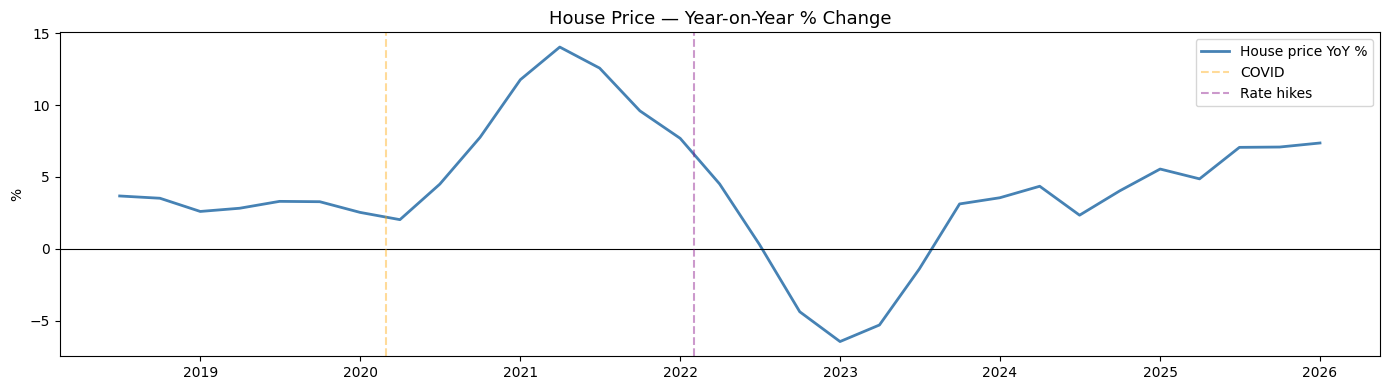

In [32]:
# Year-on-year % change (4 quarters back)
df_yoy = df_clean.pct_change(4) * 100
df_yoy.columns = [f'{c}_yoy' for c in df_yoy.columns]

print('ADF Test Results — Year-on-Year % Change')
print('-' * 65)
for col in df_yoy.columns:
    adf_test(df_yoy[col].dropna(), col)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_yoy.index, df_yoy['house_price_index_yoy'],
        color='steelblue', linewidth=2, label='House price YoY %')
ax.axhline(0, color='black', linewidth=0.8)
#ax.axvline(pd.Timestamp('2008-09-01'), color='red', linestyle='--', alpha=0.4, label='2008 crisis')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.4, label='COVID')
ax.axvline(pd.Timestamp('2022-02-01'), color='purple', linestyle='--', alpha=0.4, label='Rate hikes')
ax.set_title('House Price — Year-on-Year % Change', fontsize=13)
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/plot_yoy.png', dpi=150)
plt.show()

---
## 4. Feature engineering

We build features from the **differenced** series to avoid spurious correlations.

Features created:
- **Lagged prices**: t-1, t-4, t-8 quarters (autoregressive signal)
- **Lagged predictors**: interest rate, unemployment at t-1 and t-4
- **Rolling statistics**: 4-quarter rolling mean and std of price changes
- **Year-on-year changes** for all predictors

In [33]:
# Work in first differences
fd = df_diff.copy()
fd.columns = [f'd_{c}' for c in fd.columns]

# Also keep YoY % change for target
target_yoy = df_yoy['house_price_index_yoy'].copy()

# Build feature dataframe
features = pd.DataFrame(index=df_clean.index)

# ── Target variable ──────────────────────────────────────────────────────────
features['target_yoy'] = target_yoy  # year-on-year % change in house prices
features['target_diff'] = df_diff['house_price_index']  # quarter-on-quarter change

# ── Autoregressive lags (price) ──────────────────────────────────────────────
for lag in [1, 2, 4, 8]:
    features[f'price_lag{lag}'] = df_clean['house_price_index'].shift(lag)
    features[f'price_diff_lag{lag}'] = df_diff['house_price_index'].shift(lag)

# ── Rolling statistics ────────────────────────────────────────────────────────
price_diff = df_diff['house_price_index']
features['price_roll4_mean'] = price_diff.rolling(4).mean()
features['price_roll4_std']  = price_diff.rolling(4).std()
features['price_roll8_mean'] = price_diff.rolling(8).mean()

# ── Macroeconomic features (lagged to avoid look-ahead bias) ─────────────────
for col in ['interest_rate', 'unemployment', 'population']:
    if col in df_clean.columns:
        # Level lags
        features[f'{col}_lag1'] = df_clean[col].shift(1)
        features[f'{col}_lag4'] = df_clean[col].shift(4)
        # Differenced lags
        features[f'd_{col}_lag1'] = df_diff[col].shift(1) if col in df_diff.columns else np.nan
        # YoY change
        features[f'{col}_yoy'] = df_yoy[f'{col}_yoy'].shift(1) if f'{col}_yoy' in df_yoy.columns else np.nan

print('Feature matrix shape:', features.shape)
print('\nFeatures created:')
for col in features.columns:
    print(f'  {col}')

Feature matrix shape: (35, 25)

Features created:
  target_yoy
  target_diff
  price_lag1
  price_diff_lag1
  price_lag2
  price_diff_lag2
  price_lag4
  price_diff_lag4
  price_lag8
  price_diff_lag8
  price_roll4_mean
  price_roll4_std
  price_roll8_mean
  interest_rate_lag1
  interest_rate_lag4
  d_interest_rate_lag1
  interest_rate_yoy
  unemployment_lag1
  unemployment_lag4
  d_unemployment_lag1
  unemployment_yoy
  population_lag1
  population_lag4
  d_population_lag1
  population_yoy


In [34]:
# Drop rows with NaN (from lags and rolling windows)
features_clean = features.dropna()
print('Shape before dropna:', features.shape)
print('Shape after dropna: ', features_clean.shape)
print('\nDate range:', features_clean.index.min(), 'to', features_clean.index.max())
print(f'\nUsable quarters for modelling: {len(features_clean)}')

Shape before dropna: (35, 25)
Shape after dropna:  (26, 25)

Date range: 2019-10-01 00:00:00 to 2026-01-01 00:00:00

Usable quarters for modelling: 26


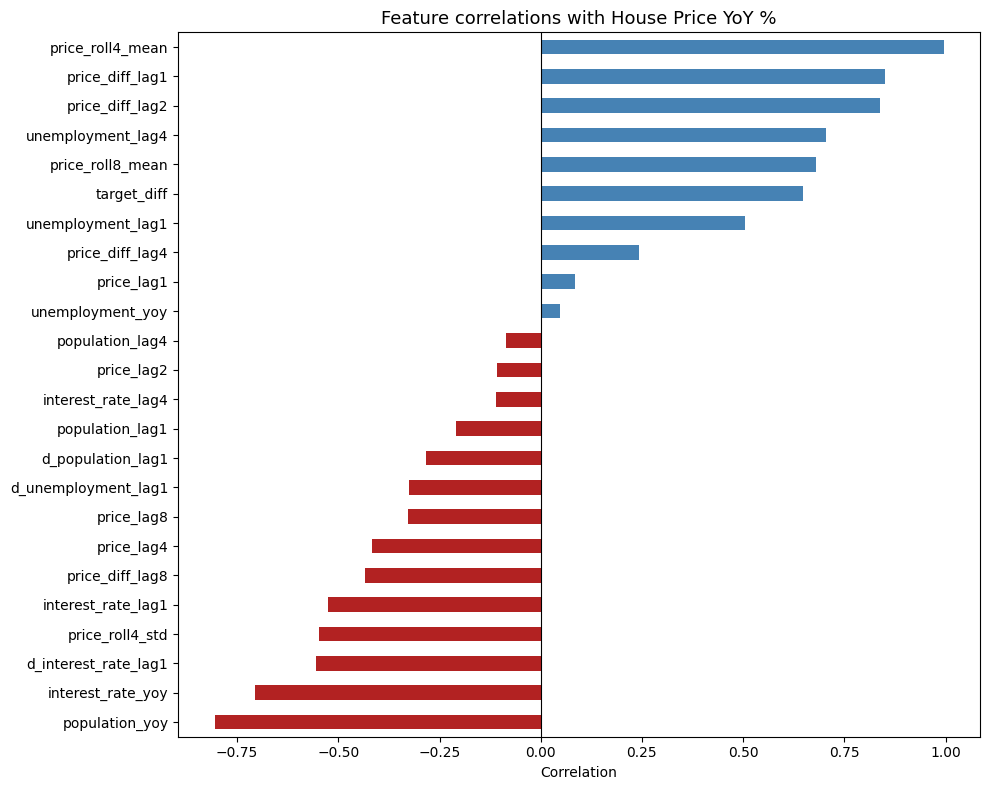


Top positive correlates:
price_roll8_mean     0.680493
unemployment_lag4    0.705358
price_diff_lag2      0.839031
price_diff_lag1      0.849760
price_roll4_mean     0.994974
Name: target_yoy, dtype: float64

Top negative correlates:
population_yoy         -0.805638
interest_rate_yoy      -0.705362
d_interest_rate_lag1   -0.554189
price_roll4_std        -0.546932
interest_rate_lag1     -0.525618
Name: target_yoy, dtype: float64


In [35]:
# Correlation of features with target_yoy
corr = features_clean.corr()['target_yoy'].drop('target_yoy').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['firebrick' if c < 0 else 'steelblue' for c in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature correlations with House Price YoY %', fontsize=13)
ax.set_xlabel('Correlation')
plt.tight_layout()
#plt.savefig('data/processed/plot_feature_correlations.png', dpi=150)
plt.show()

print('\nTop positive correlates:')
print(corr.tail(5))
print('\nTop negative correlates:')
print(corr.head(5))

In [36]:
# Check: does interest rate correlation flip negative after differencing?
print('Interest rate correlations with house price YoY%:')
ir_cols = [c for c in features_clean.columns if 'interest' in c]
for col in ir_cols:
    r = features_clean[col].corr(features_clean['target_yoy'])
    print(f'  {col:35s}: {r:.3f}')

Interest rate correlations with house price YoY%:
  interest_rate_lag1                 : -0.526
  interest_rate_lag4                 : -0.110
  d_interest_rate_lag1               : -0.554
  interest_rate_yoy                  : -0.705


---
## 5. Train / test split

**Critical rule for time series:** never use random splits.  
Always respect temporal order — train on the past, test on the future.

We hold out the last 8 quarters (2 years) as the test set.

In [37]:
TEST_QUARTERS = 8  # hold out last 2 years

train = features_clean.iloc[:-TEST_QUARTERS]
test  = features_clean.iloc[-TEST_QUARTERS:]

print(f'Train: {len(train)} quarters  ({train.index.min().date()} to {train.index.max().date()})')
print(f'Test:  {len(test)} quarters  ({test.index.min().date()} to {test.index.max().date()})')

# Define X and y
TARGET = 'target_yoy'
FEATURES = [c for c in features_clean.columns if c not in ['target_yoy', 'target_diff']]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'\nNumber of features: {len(FEATURES)}')
print(f'Features: {FEATURES}')

Train: 18 quarters  (2019-10-01 to 2024-01-01)
Test:  8 quarters  (2024-04-01 to 2026-01-01)

Number of features: 23
Features: ['price_lag1', 'price_diff_lag1', 'price_lag2', 'price_diff_lag2', 'price_lag4', 'price_diff_lag4', 'price_lag8', 'price_diff_lag8', 'price_roll4_mean', 'price_roll4_std', 'price_roll8_mean', 'interest_rate_lag1', 'interest_rate_lag4', 'd_interest_rate_lag1', 'interest_rate_yoy', 'unemployment_lag1', 'unemployment_lag4', 'd_unemployment_lag1', 'unemployment_yoy', 'population_lag1', 'population_lag4', 'd_population_lag1', 'population_yoy']


In [39]:
# Save everything
features_clean.to_csv('../data/processed/features.csv')
train.to_csv('../data/processed/train.csv')
test.to_csv('../data/processed/test.csv')

print('Saved:')
print('  data/processed/features.csv')
print('  data/processed/train.csv')
print('  data/processed/test.csv')
print(f'\nReady for modelling. Target: {TARGET}')
print(f'Train size: {len(train)}, Test size: {len(test)}')

Saved:
  data/processed/features.csv
  data/processed/train.csv
  data/processed/test.csv

Ready for modelling. Target: target_yoy
Train size: 18, Test size: 8


---
## Summary

**Stationarity:** All series were non-stationary in levels. First differencing achieved stationarity for all variables.

**Target variable:** Year-on-year % change in house price index — interpretable, stationary, and directly relevant for forecasting.

**Features created:**
- Autoregressive lags: price at t-1, t-2, t-4, t-8
- Rolling statistics: 4q and 8q rolling mean and std of price changes
- Macroeconomic lags: interest rate, unemployment, population at t-1 and t-4
- YoY changes for all macroeconomic variables

**Key finding:** After differencing, interest rate correlation with house prices should be negative — consistent with economic theory.

**Train/test split:** Last 8 quarters held out as test set (temporal order respected).